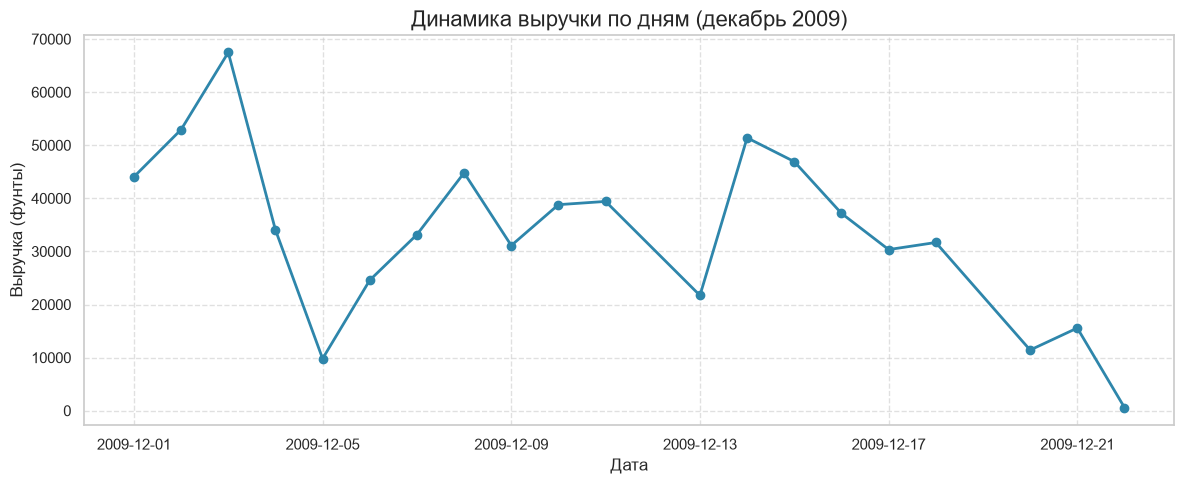

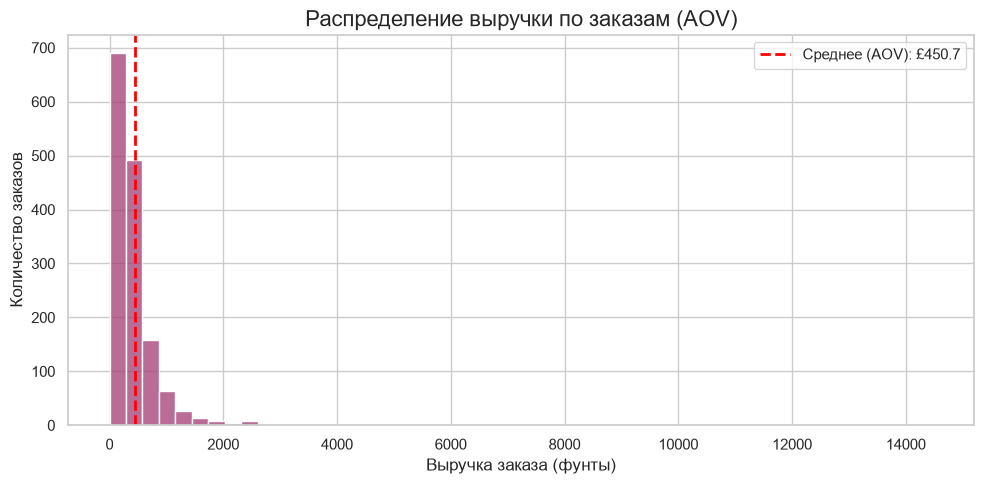

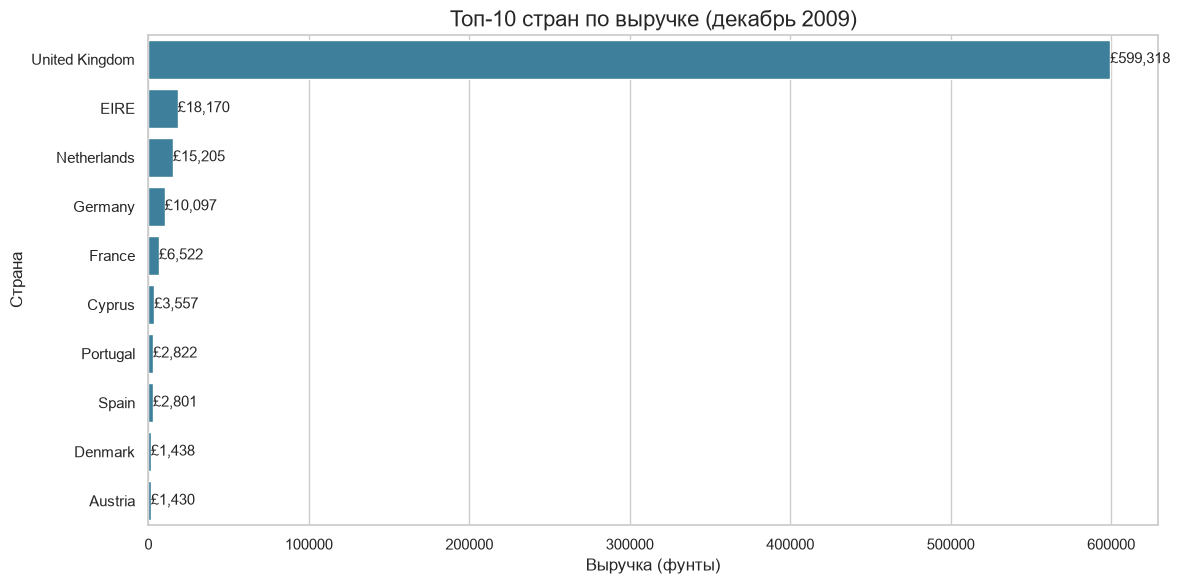

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Подготовка и нормализация колонок ---
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Сохраняем сырые данные ДО очистки
df_raw = df.copy()

# --- 2. Очистка данных ---
df = df.dropna(subset=["customer_id"])
df = df[(df["quantity"] > 0) & (df["price"] > 0)]
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

# Создаём признаки
df["total_price"] = df["quantity"] * df["price"]
df["date"] = df["invoicedate"].dt.date
df["hour"] = df["invoicedate"].dt.hour
df["dayofweek"] = df["invoicedate"].dt.day_name()

# --- 3. Расчёт метрик ---
daily_revenue = df.groupby("date")["total_price"].sum()
order_revenue = df.groupby("invoice")["total_price"].sum()

# Считаем выручку по странам для 3-го графика
revenue_by_country = df.groupby("country")["total_price"].sum()
top_countries_revenue = revenue_by_country.nlargest(10)

# (Опционально) Возвраты
returns = df_raw[df_raw["quantity"] < 0]
total_by_country = df_raw.groupby("country").size()
returns_by_country = returns.groupby("country").size()
return_rate_by_country = (returns_by_country / total_by_country).fillna(0) * 100
top_countries_returns = return_rate_by_country.nlargest(10)

# --- 4. Визуализация ---
# УДАЛИЛИ os.makedirs, так как папка ../reports уже создана вручную
sns.set(style="whitegrid")

# === ГРАФИК 1: Динамика выручки по дням ===
plt.figure(figsize=(12, 5))
if not daily_revenue.empty:
    daily_revenue_sorted = daily_revenue.sort_index()
    plt.plot(daily_revenue_sorted.index, daily_revenue_sorted.values, marker="o", linewidth=2, color="#2E86AB")
    plt.title("Динамика выручки по дням (декабрь 2009)", fontsize=16)
    plt.xlabel("Дата", fontsize=12)
    plt.ylabel("Выручка (фунты)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
else:
    plt.text(0.5, 0.5, "Нет данных для отображения", ha='center', va='center', fontsize=14)
plt.tight_layout()
# Сохраняем НА УРОВЕНЬ ВЫШЕ
plt.savefig("../reports/daily_revenue.png", dpi=300)
plt.show()

# === ГРАФИК 2: Распределение выручки по заказам (AOV) ===
plt.figure(figsize=(10, 5))
if not order_revenue.empty:
    sns.histplot(order_revenue, bins=50, color="#A23B72", kde=False)
    plt.title("Распределение выручки по заказам (AOV)", fontsize=16)
    plt.xlabel("Выручка заказа (фунты)", fontsize=12)
    plt.ylabel("Количество заказов", fontsize=12)
    plt.axvline(order_revenue.mean(), color="red", linestyle="--", linewidth=2,
                label=f"Среднее (AOV): £{order_revenue.mean():.1f}")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Нет данных для отображения", ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig("../reports/aov_distribution.png", dpi=300)
plt.show()

# === ГРАФИК 3: Топ-10 стран по выручке ===
plt.figure(figsize=(12, 6))
if not top_countries_revenue.empty:
    sns.barplot(
        x=top_countries_revenue.values,
        y=top_countries_revenue.index,
        color="#2E86AB"
    )
    plt.title("Топ-10 стран по выручке (декабрь 2009)", fontsize=16)
    plt.xlabel("Выручка (фунты)", fontsize=12)
    plt.ylabel("Страна", fontsize=12)

    # Добавляем значения на столбцы
    for i, v in enumerate(top_countries_revenue.values):
        plt.text(v + 100, i, f"£{v:,.0f}", va="center", fontsize=11)
else:
    plt.text(0.5, 0.5, "Нет данных для отображения", ha='center', va='center', fontsize=14)
    
plt.tight_layout()
plt.savefig("../reports/top_countries_revenue.png", dpi=300)
plt.show()
